In [1]:
import pandas as pd
df = pd.read_csv("../Dataset/Global_Superstore.csv.csv")
df.head()

,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,...,category,sub_category,product_name,sales,quantity,discount,profit,shipping_cost,order_priority,year
0,AG-2011-2040,1/1/2011,6/1/2011,Standard Class,Toby Braunhardt,Consumer,Constantine,Algeria,Africa,Africa,...,Office Supplies,Storage,"Tenex Lockers, Blue",408,2,0.0,106.140,35.46,Medium,2011
1,IN-2011-47883,1/1/2011,8/1/2011,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Office Supplies,Supplies,"Acme Trimmer, High Speed",120,3,0.1,36.036,9.72,Medium,2011
2,HU-2011-1220,1/1/2011,5/1/2011,Second Class,Annie Thurman,Consumer,Budapest,Hungary,EMEA,EMEA,...,Office Supplies,Storage,"Tenex Box, Single Width",66,4,0.0,29.640,8.17,High,2011
3,IT-2011-3647632,1/1/2011,5/1/2011,Second Class,Eugene Moren,Home Office,Stockholm,Sweden,EU,North,...,Office Supplies,Paper,"Enermax Note Cards, Premium",45,3,0.5,-26.055,4.82,High,2011
4,IN-2011-47883,1/1/2011,8/1/2011,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Furniture,Furnishings,"Eldon Light Bulb, Duo Pack",114,5,0.1,37.770,4.70,Medium,2011


In [2]:
df.shape

(51290, 21)

In [3]:
df.columns

Index(['order_id', 'order_date', 'ship_date', 'ship_mode', 'customer_name',
       'segment', 'state', 'country', 'market', 'region', 'product_id',
       'category', 'sub_category', 'product_name', 'sales', 'quantity',
       'discount', 'profit', 'shipping_cost', 'order_priority', 'year'],
      dtype='object')

In [4]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   order_id        51290 non-null  object 
 1   order_date      51290 non-null  object 
 2   ship_date       51290 non-null  object 
 3   ship_mode       51290 non-null  object 
 4   customer_name   51290 non-null  object 
 5   segment         51290 non-null  object 
 6   state           51290 non-null  object 
 7   country         51290 non-null  object 
 8   market          51290 non-null  object 
 9   region          51290 non-null  object 
 10  product_id      51290 non-null  object 
 11  category        51290 non-null  object 
 12  sub_category    51290 non-null  object 
 13  product_name    51290 non-null  object 
 14  sales           51290 non-null  object 
 15  quantity        51290 non-null  int64  
 16  discount        51290 non-null  float64
 17  profit          51290 non-null 

In [5]:
df.describe()

,quantity,discount,profit,shipping_cost,year
count,51290.000000,51290.000000,51290.000000,51290.000000,51290.000000
mean,3.476545,0.142908,28.641740,26.375915,2012.777208
std,2.278766,0.212280,174.424113,57.296804,1.098931
min,1.000000,0.000000,-6599.978000,0.000000,2011.000000
25%,2.000000,0.000000,0.000000,2.610000,2012.000000
50%,3.000000,0.000000,9.240000,7.790000,2013.000000
75%,5.000000,0.200000,36.810000,24.450000,2014.000000
max,14.000000,0.850000,8399.976000,933.570000,2014.000000


In [6]:
df['sales'].head(10)

0    408
1    120
2     66
3     45
4    114
5     55
6    314
7    276
8    912
9    667
Name: sales, dtype: object

In [7]:
df['sales'].sample(20)

6247       177
16624       56
10305       34
43314       20
27970       27
10482        7
33919        5
10499       70
35953      119
2663        13
12325       84
5864        32
36092       20
22430       43
41797    3,234
7312     1,026
30740      124
2070       128
12471      201
22470       81
Name: sales, dtype: object

In [8]:
df['sales'] = df['sales'].str.replace(',', '')

In [9]:
df['sales'].sample(5)

44099     260
14911     110
24758       9
41868    4192
33207     161
Name: sales, dtype: object

In [10]:
df['sales'] = df['sales'].astype(float)

In [11]:
df['sales'].dtype

dtype('float64')

In [12]:
df['sales'].sum()

np.float64(12642905.0)

In [13]:
df['sales'].mean()


np.float64(246.49844024176252)

In [14]:
df['sales'].max()

22638.0

In [15]:
df[df['sales'] == df['sales'].max()]

,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,...,category,sub_category,product_name,sales,quantity,discount,profit,shipping_cost,order_priority,year
1103,CA-2011-145317,18-03-2011,23-03-2011,Standard Class,Sean Miller,Home Office,Florida,United States,US,South,...,Technology,Machines,Cisco TelePresence System EX90 Videoconferenci...,22638.0,6,0.5,-1811.0784,24.29,Medium,2011


In [16]:
df[['discount', 'profit']].corr()

,discount,profit
discount,1.000000,-0.316375
profit,-0.316375,1.000000


In [17]:
df.groupby('category')['sales'].sum().sort_values(ascending=False)

category
Technology         4744691.0
Furniture          4110884.0
Office Supplies    3787330.0
Name: sales, dtype: float64

In [18]:
(df.groupby('category')['sales'].sum() / df['sales'].sum() * 100).round(2)

category
Furniture          32.52
Office Supplies    29.96
Technology         37.53
Name: sales, dtype: float64

In [19]:
df.groupby('category')['profit'].sum().sort_values(ascending=False)

category
Technology         663778.73318
Office Supplies    518473.83430
Furniture          286782.25380
Name: profit, dtype: float64

In [20]:
(df.groupby('category')['profit'].sum() /
 df.groupby('category')['sales'].sum() * 100).round(2)


category
Furniture           6.98
Office Supplies    13.69
Technology         13.99
dtype: float64

In [21]:
df.groupby('customer_name')['sales'].sum().sort_values(ascending=False).head(10)

customer_name
Tom Ashbrook          40489.0
Tamara Chand          37453.0
Greg Tran             35552.0
Christopher Conant    35187.0
Sean Miller           35170.0
Bart Watters          32315.0
Natalie Fritzler      31778.0
Fred Hopkins          30404.0
Jane Waco             30288.0
Hunter Lopez          30246.0
Name: sales, dtype: float64

In [22]:
df.groupby('customer_name')['profit'].sum().sort_values(ascending=False).head(10)

customer_name
Tamara Chand       8672.89890
Raymond Buch       8453.04950
Sanjit Chand       8205.37990
Hunter Lopez       7816.56778
Bill Eplett        7410.00530
Harry Marie        6958.28640
Susan Pistek       6484.40726
Mike Gockenbach    6458.67620
Adrian Barton      6417.28450
Tom Ashbrook       6311.97910
Name: profit, dtype: float64

In [23]:
df.groupby('region')['sales'].sum().sort_values(ascending=False)

region
Central           2822399.0
South             1600960.0
North             1248192.0
Oceania           1100207.0
Southeast Asia     884438.0
North Asia         848349.0
EMEA               806184.0
Africa             783776.0
Central Asia       752839.0
West               725514.0
East               678834.0
Caribbean          324281.0
Canada              66932.0
Name: sales, dtype: float64

In [24]:
df.groupby('product_name')['sales'].sum().sort_values(ascending=False).head(10)


product_name
Apple Smart Phone, Full Size                                86936.0
Cisco Smart Phone, Full Size                                76441.0
Motorola Smart Phone, Full Size                             73159.0
Nokia Smart Phone, Full Size                                71904.0
Canon imageCLASS 2200 Advanced Copier                       61600.0
Hon Executive Leather Armchair, Adjustable                  58200.0
Office Star Executive Leather Armchair, Adjustable          50667.0
Harbour Creations Executive Leather Armchair, Adjustable    50120.0
Samsung Smart Phone, Cordless                               48654.0
Nokia Smart Phone, with Caller ID                           47880.0
Name: sales, dtype: float64

In [25]:
df.groupby('product_name')['profit'].sum().sort_values(ascending=False).head(10)

product_name
Canon imageCLASS 2200 Advanced Copier                       25199.9280
Cisco Smart Phone, Full Size                                17238.5206
Motorola Smart Phone, Full Size                             17027.1130
Hoover Stove, Red                                           11807.9690
Sauder Classic Bookcase, Traditional                        10672.0730
Harbour Creations Executive Leather Armchair, Adjustable    10427.3260
Nokia Smart Phone, Full Size                                 9938.1955
Cisco Smart Phone, with Caller ID                            9786.6408
Nokia Smart Phone, with Caller ID                            9465.3257
Belkin Router, USB                                           8955.0180
Name: profit, dtype: float64

In [26]:
df.groupby('year')['sales'].sum()

year
2011    2259511.0
2012    2677493.0
2013    3405860.0
2014    4300041.0
Name: sales, dtype: float64

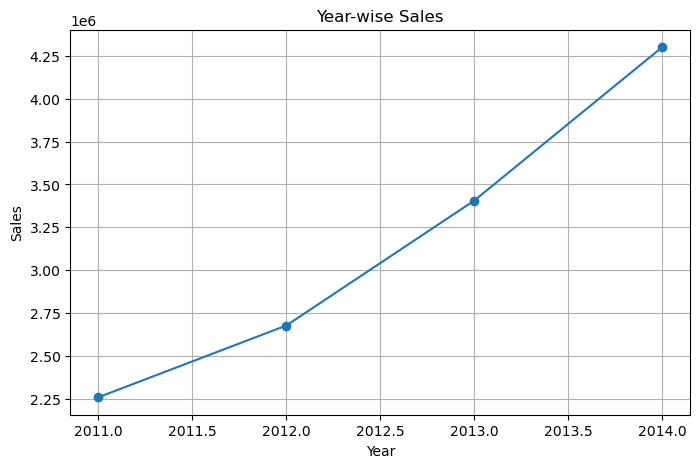

In [27]:
import matplotlib.pyplot as plt

year_sales = df.groupby('year')['sales'].sum()

plt.figure(figsize=(8,5))
plt.plot(year_sales.index, year_sales.values, marker='o')
plt.title("Year-wise Sales")
plt.xlabel("Year")
plt.ylabel("Sales")
plt.grid(True)

plt.show()

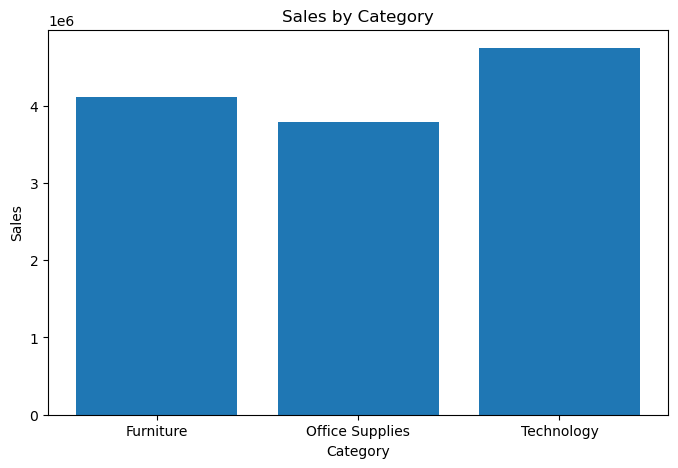

In [28]:
category_sales = df.groupby('category')['sales'].sum()

plt.figure(figsize=(8,5))
plt.bar(category_sales.index, category_sales.values)

plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales")

plt.show()

([<matplotlib.patches.Wedge at 0x161af7b06e0>,
 [Text(0.5742962645748201, 0.9381811128430418, 'Furniture'),
  Text(-1.0863860280491675, 0.17252651407697794, 'Office Supplies'),
  Text(0.42004219871713755, -1.016643768139496, 'Technology')],
 [Text(0.31325250794990184, 0.5117351524598409, '32.5%'),
  Text(-0.5925741971177276, 0.09410537131471523, '30.0%'),
  Text(0.2291139265729841, -0.554532964439725, '37.5%')])

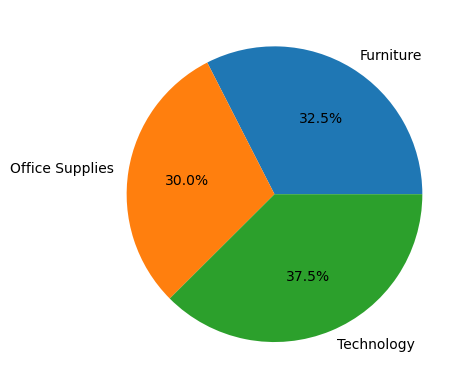

In [29]:
plt.pie(category_sales.values,
        labels=category_sales.index,
        autopct='%1.1f%%')

<BarContainer object of 3 artists>

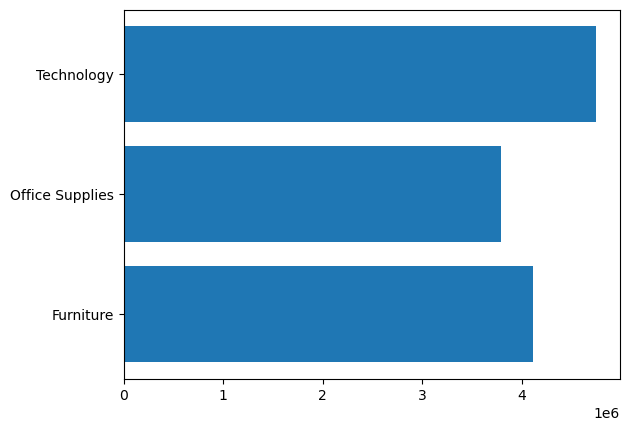

In [30]:
plt.barh(category_sales.index, category_sales.values)

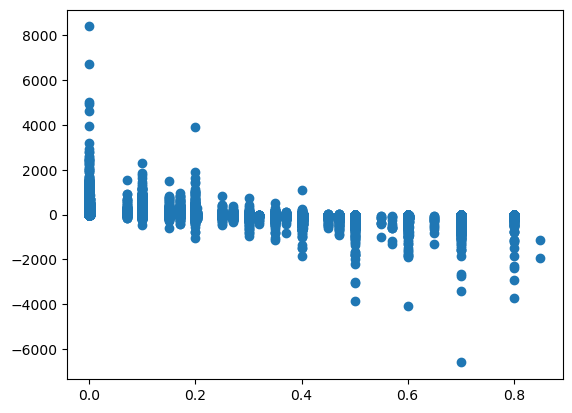

In [31]:
plt.scatter(df['discount'], df['profit'])

(array([5.075e+04, 4.800e+02, 4.400e+01, 8.000e+00, 5.000e+00, 0.000e+00,
        1.000e+00, 1.000e+00, 0.000e+00, 1.000e+00]),
 array([    0. ,  2263.8,  4527.6,  6791.4,  9055.2, 11319. , 13582.8,
        15846.6, 18110.4, 20374.2, 22638. ]),
 <BarContainer object of 10 artists>)

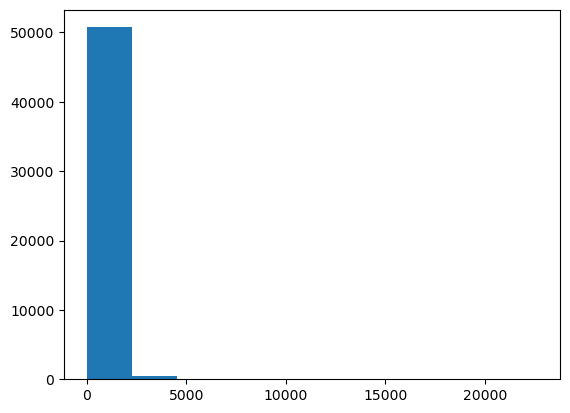

In [32]:
plt.hist(df['sales'])

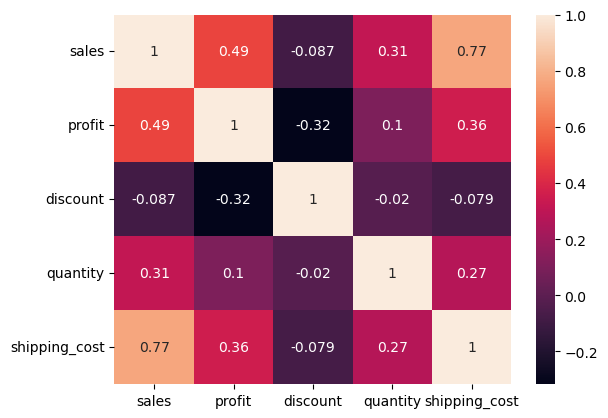

In [33]:
# 1
import seaborn as sns

# 2
corr_matrix = df[['sales','profit','discount','quantity','shipping_cost']].corr()

# 3
sns.heatmap(corr_matrix, annot=True)

# 4
plt.show()

In [34]:
df.groupby('product_name')['quantity'].sum().sort_values(ascending=False).head(10)

product_name
Staples                                  876
Cardinal Index Tab, Clear                337
Eldon File Cart, Single Width            321
Rogers File Cart, Single Width           262
Sanford Pencil Sharpener, Water Color    259
Stockwell Paper Clips, Assorted Sizes    253
Avery Index Tab, Clear                   252
Ibico Index Tab, Clear                   251
Smead File Cart, Single Width            250
Stanley Pencil Sharpener, Water Color    242
Name: quantity, dtype: int64

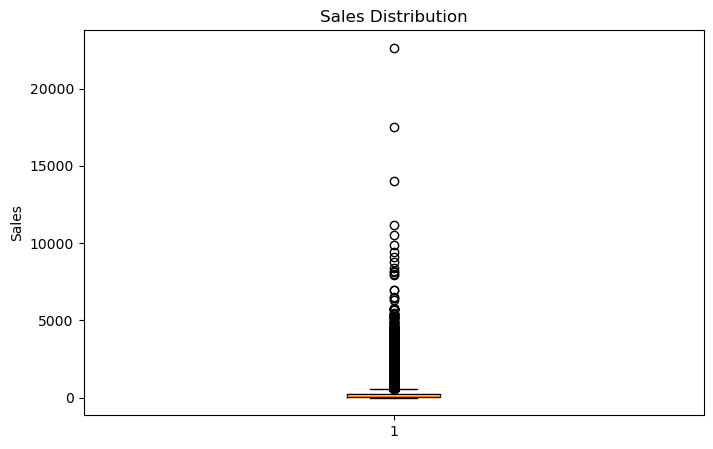

In [35]:
plt.figure(figsize=(8,5))

plt.boxplot(df['sales'])

plt.title("Sales Distribution")

plt.ylabel("Sales")

plt.show()

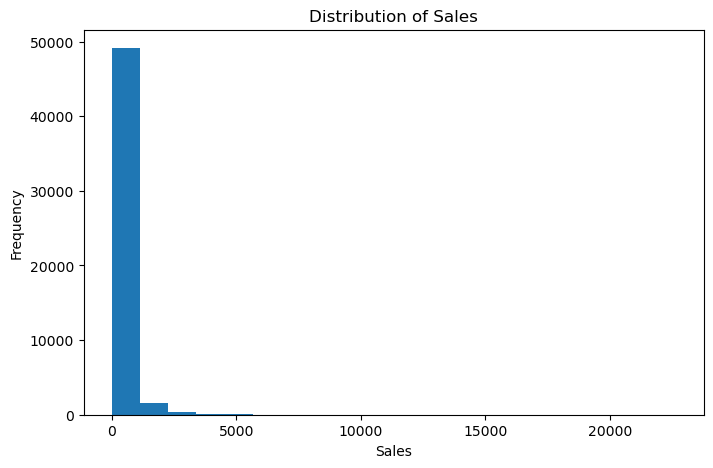

In [36]:
plt.figure(figsize=(8,5))

plt.hist(df['sales'], bins=20)

plt.title("Distribution of Sales")
plt.xlabel("Sales")
plt.ylabel("Frequency")

plt.show()

In [37]:
plt.figure(figsize=(15,10))

<Figure size 1500x1000 with 0 Axes>

<Figure size 1500x1000 with 0 Axes>

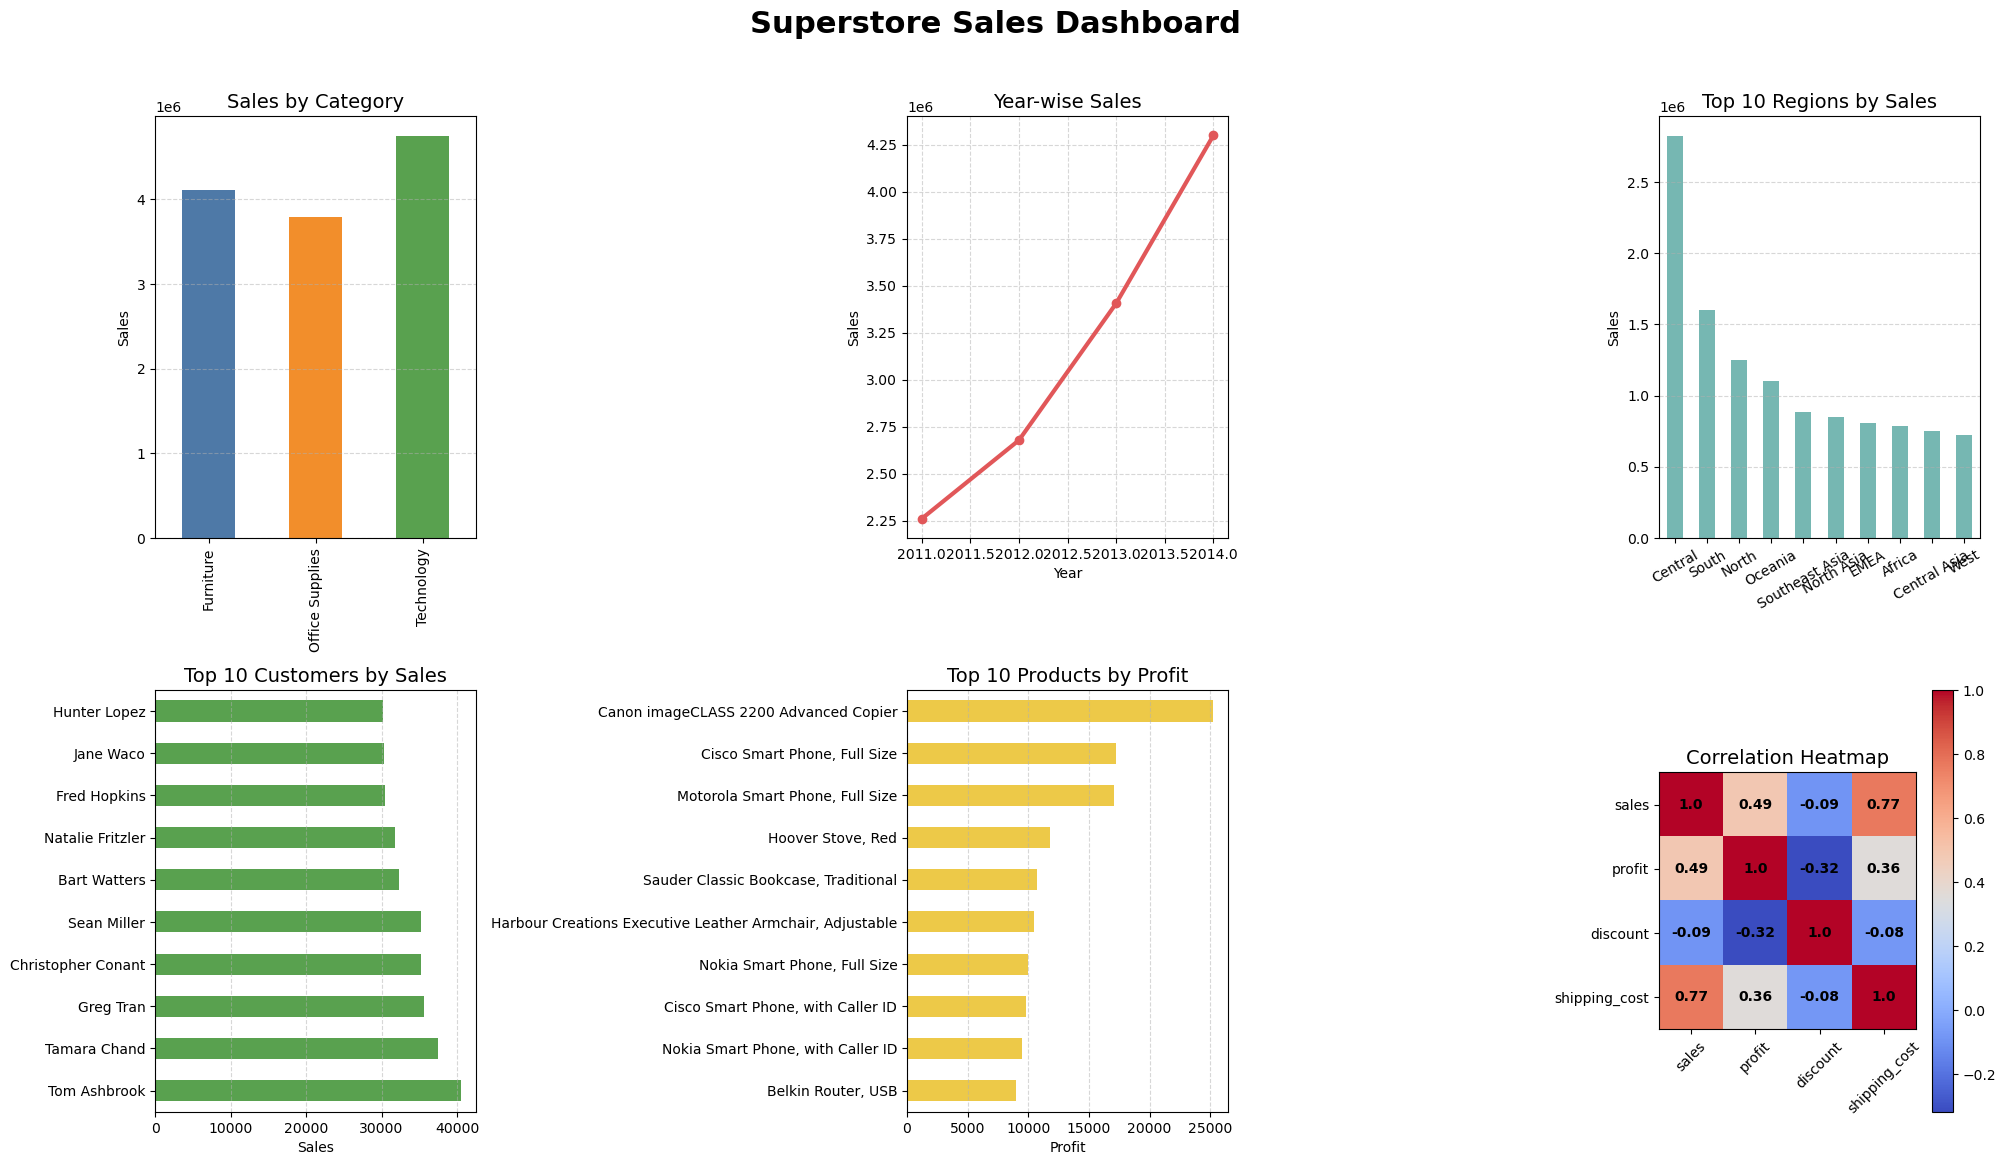

In [38]:
import matplotlib.pyplot as plt
import numpy as np

# ===========================
# SALES DASHBOARD
# ===========================

plt.figure(figsize=(20,12))
plt.suptitle("Superstore Sales Dashboard", fontsize=22, fontweight='bold')

# ----------------------------------
# Plot 1 - Sales by Category
# ----------------------------------
plt.subplot(2,3,1)

df.groupby('category')['sales'].sum().plot(
    kind='bar',
    color=['#4E79A7','#F28E2B','#59A14F']
)

plt.title("Sales by Category", fontsize=14)
plt.xlabel("")
plt.ylabel("Sales")
plt.grid(axis='y', linestyle='--', alpha=0.5)

# ----------------------------------
# Plot 2 - Year-wise Sales
# ----------------------------------
plt.subplot(2,3,2)

df.groupby('year')['sales'].sum().plot(
    kind='line',
    marker='o',
    linewidth=3,
    color='#E15759'
)

plt.title("Year-wise Sales", fontsize=14)
plt.xlabel("Year")
plt.ylabel("Sales")
plt.grid(True, linestyle='--', alpha=0.5)

# ----------------------------------
# Plot 3 - Top Regions
# ----------------------------------
plt.subplot(2,3,3)

df.groupby('region')['sales'].sum().sort_values(ascending=False).head(10).plot(
    kind='bar',
    color='#76B7B2'
)

plt.title("Top 10 Regions by Sales", fontsize=14)
plt.xlabel("")
plt.ylabel("Sales")
plt.xticks(rotation=30)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# ----------------------------------
# Plot 4 - Top Customers
# ----------------------------------
plt.subplot(2,3,4)

df.groupby('customer_name')['sales'].sum().sort_values(ascending=False).head(10).plot(
    kind='barh',
    color='#59A14F'
)

plt.title("Top 10 Customers by Sales", fontsize=14)
plt.xlabel("Sales")
plt.ylabel("")
plt.grid(axis='x', linestyle='--', alpha=0.5)

# ----------------------------------
# Plot 5 - Top Products
# ----------------------------------
plt.subplot(2,3,5)

df.groupby('product_name')['profit'].sum().sort_values().tail(10).plot(
    kind='barh',
    color='#EDC948'
)

plt.title("Top 10 Products by Profit", fontsize=14)
plt.xlabel("Profit")
plt.ylabel("")
plt.grid(axis='x', linestyle='--', alpha=0.5)

# ----------------------------------
# Plot 6 - Correlation Heatmap
# ----------------------------------
plt.subplot(2,3,6)

corr = df[['sales','profit','discount','shipping_cost']].corr()

plt.imshow(corr, cmap='coolwarm')

plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.columns)), corr.columns)

# Show correlation values
for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        plt.text(
            j,
            i,
            round(corr.iloc[i,j],2),
            ha='center',
            va='center',
            color='black',
            fontsize=10,
            fontweight='bold'
        )

plt.title("Correlation Heatmap", fontsize=14)

plt.tight_layout(rect=[0,0,1,0.96])
plt.savefig("Sales_Dashboard.png", dpi=300, bbox_inches="tight")
plt.show()

In [41]:
df.to_csv("../Dataset/Global_Superstore_Clean.csv", index=False)